# 09 Interactive SRG Explorer

`eucare.shrink_rotate.ShrinkRotateExplorer` packages an interactive widget on top of an SRG graph: drag the sliders to vary the shrink factor and rotation angle and see the crease pattern update live. Toggle *folded* to preview the folded form, or *reparametrized* to switch to the equivalent (β, γ) parametrisation.

Requires a Jupyter kernel with `%matplotlib widget`.

In [1]:
%matplotlib widget
import eucare as ec
from eucare.example_graphs import from_tiles
from eucare.example_tilesets import t_4_6_12
from eucare.shrink_rotate import (
    assign_this_way_by_face_z_order,
    shrink_rotate_pattern,
)
from eucare.shrink_rotate import ShrinkRotateExplorer

In [2]:
# Build a tiling, assign face z-order (controls mountain/valley), and build the SRG.
G = from_tiles(t_4_6_12(), rings=3)
for f in G.faces:
    f['z_order'] = f.order()
assign_this_way_by_face_z_order(G)

SRG = shrink_rotate_pattern(G)
SRG.join_order_2_boundary_vertices()  # make the boundary a little nicer

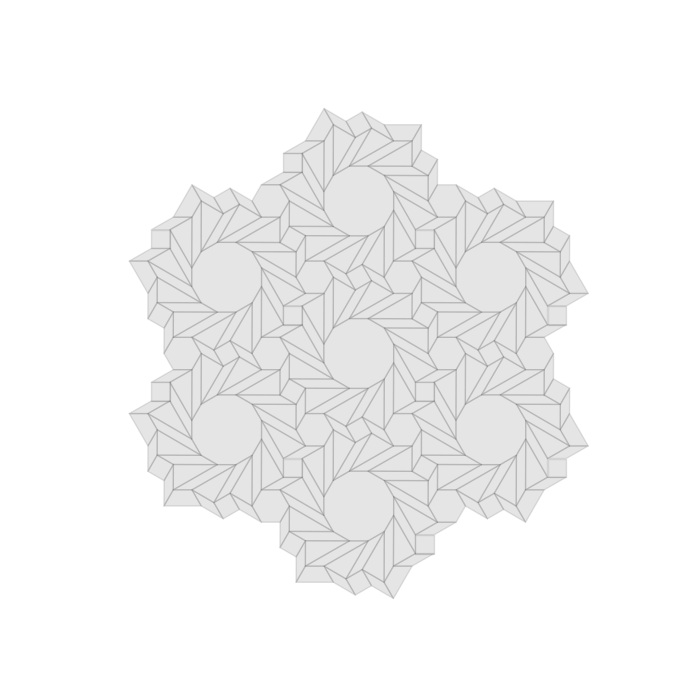

Output()

In [3]:
explorer = ShrinkRotateExplorer(SRG)
explorer.display()

The widget mutates `v['pos']` on the SRG in place at every change, so downstream operations like `eucare.overlap.fold_complete(SRG)` always operate on the currently-displayed geometry.

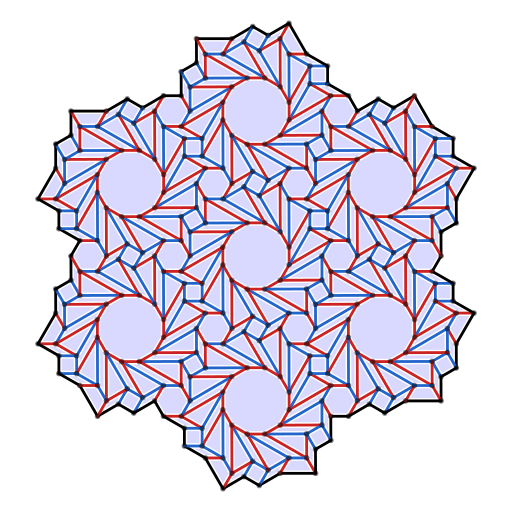

In [4]:
SRG.show()

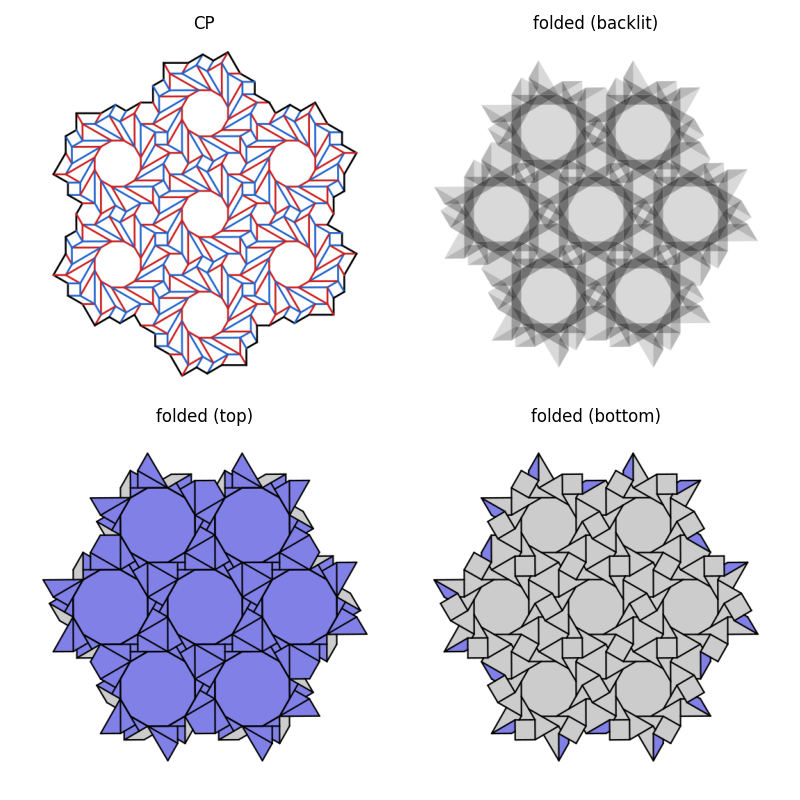

In [5]:
SRG.recompute_lengths_and_angles()
results = ec.overlap.fold_complete(SRG.copy(), quiet=True, overlap_eps=1e-6)
results.show()